In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Proses ekstraksi data
data = pd.read_csv('/content/drive/MyDrive/[Kompi 2] COMPLETARE/dataset/HDI INDONESIA.csv')

# Tampilkan data
display(data)

,countryIsoCode,country,indexCode,index,dimension,indicatorCode,indicator,year,value
0,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1990,0.526
1,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1991,0.533
2,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1992,0.541
3,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1993,0.549
4,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1994,0.560
5,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1995,0.571
6,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1996,0.580
7,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1997,0.590
8,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1998,0.587
9,IDN,Indonesia,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1999,0.592


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   countryIsoCode  33 non-null     object 
 1   country         33 non-null     object 
 2   indexCode       33 non-null     object 
 3   index           33 non-null     object 
 4   dimension       0 non-null      float64
 5   indicatorCode   33 non-null     object 
 6   indicator       33 non-null     object 
 7   year            33 non-null     int64  
 8   value           33 non-null     float64
dtypes: float64(2), int64(1), object(6)
memory usage: 2.4+ KB


In [ ]:
data1 = data.copy()
df = data1[['year', 'value']]
df

,year,value
0,1990,0.526
1,1991,0.533
2,1992,0.541
3,1993,0.549
4,1994,0.560
5,1995,0.571
6,1996,0.580
7,1997,0.590
8,1998,0.587
9,1999,0.592


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    33 non-null     int64  
 1   value   33 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 656.0 bytes


Terlihat kolom year type datanya masih int ini perlu di konversi ke type datetime

nanti kita ganti dibawah

# Plot Timeseries

In [ ]:
# Import library plotly untuk visualisasi data
import numpy as np
import plotly.express as px

def plot_timeseries(
    data : pd.DataFrame,
    value : str,
    judul : str,
    warna : str = 'black',
    showxaxis : bool = False,
    showtrend : bool = False,
):
    fig = px.line(
        data_frame = data,
        x = data.index,
        y = value,
        color_discrete_sequence = [warna]
    )

    if(showtrend):
        # Hitung koefisien regresi linier
        coefficients = np.polyfit(range(len(data)), data[value].fillna(data[value].median()), 1)
        slope = coefficients[0]
        intercept = coefficients[1]

        # Tambahkan garis regresi ke plot
        fig.add_scatter(
            x = data.index,
            y = range(len(data)) * slope + intercept,
            mode = 'lines',
            line = dict(
                color = 'grey',
                dash = 'dash'
            )
        )

    if(showxaxis):
        fig.add_hline(
            y = 0,
            line = dict(
                color = 'LightSeaGreen',
                width = 2,
                dash = 'dash',
            ),
        )

    fig.update_layout(
        width = 1200,
        height = 500,
        showlegend = False,
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = judul,
            font = dict(
                size = 24,
                color = '#757882'
            ),
            y = 0.92,
            x = 0.5
        ),
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        margin = dict(
            t = 80,
            b = 10,
            r = 20
        )
    )

    fig.show(renderer = 'colab')

In [ ]:
title = f"""
  <b><span style='color:#000435'>Plot data HDI pertahun</span></b>
"""

plot_timeseries(
    data = df.set_index('year'),
    value = 'value',
    judul = title,
    warna = '#000435',
    showtrend = False,
)

Berdasarkan tren grafik Human Development Index (HDI) di Indonesia, yang datanya diambil dari UNDP, berikut adalah beberapa insight:

Peningkatan Konsisten: Secara umum, HDI Indonesia mengalami peningkatan konsisten dari tahun 1990 hingga 2020. Ini menunjukkan adanya perbaikan yang terus-menerus dalam kualitas hidup, seperti pendidikan, kesehatan, dan standar hidup.

Periode Stabil atau Pertumbuhan Lambat: Ada periode, sekitar tahun 1997-1999, di mana pertumbuhan HDI terlihat melambat. Hal ini mungkin berkaitan dengan krisis ekonomi Asia pada akhir 1990-an, yang berdampak pada berbagai aspek sosial-ekonomi Indonesia.

Pertumbuhan Cepat Setelah 2000-an: Setelah tahun 2000, HDI menunjukkan pertumbuhan yang relatif lebih cepat, sejalan dengan kebijakan pembangunan manusia yang lebih fokus di berbagai sektor, termasuk pendidikan dasar dan pelayanan kesehatan.

Konsistensi Menuju 2020: Walaupun sempat melambat dalam beberapa tahun terakhir, tren tetap positif hingga mendekati 2020. Faktor-faktor seperti investasi di bidang teknologi, pengurangan kemiskinan, dan program pembangunan desa mungkin berkontribusi terhadap tren ini.

sumber data: [LINK](https://hdr.undp.org/data-center/human-development-index#/indicies/HDI)

#Decompose

In [ ]:
# Ganti nama Kolom 'Value' jadi 'HDI'
df = df.rename(columns={'value': 'hdi'})
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    33 non-null     int64  
 1   hdi     33 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 656.0 bytes


In [ ]:
# Mengonversi kolom 'year' menjadi PeriodIndex
df['year'] = pd.to_datetime(df['year'], format='%Y')

# Menetapkan 'year' sebagai indeks
df.set_index('year', inplace=True)

In [ ]:
# Import library yang dibutuhkan
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Proses dekomposisi musiman
result = seasonal_decompose(
    df['hdi']
)

In [ ]:
# Definisikan komponen
data_plot = dict(
    data = [pd.DataFrame(result.trend), pd.DataFrame(result.seasonal), pd.DataFrame(result.resid)],
    value = ['trend', 'seasonal', 'resid'],
    color = ['#091057', '#024CAA', '#EC8305'],
    showtrend = [True, False, True]
)

# Lakukan plotting
for i in range(3):
    plot_timeseries(
        data = data_plot.get('data')[i],
        value = data_plot.get('value')[i],
        judul = f"<b><span style='color:{data_plot.get('color')[i]}'>{data_plot.get('value')[i].upper()}</span></b>",
        warna = data_plot.get('color')[i],
        showtrend = data_plot.get('showtrend')[i],
    )


1. TREND

* Grafik trend memperlihatkan pertumbuhan yang stabil dan konsisten pada HDI dari tahun 1990 hingga 2024. Ini menunjukkan adanya perbaikan kualitas pembangunan manusia selama periode waktu tersebut.
* Kenaikan stabil ini mengindikasikan keberhasilan dalam kebijakan atau program yang mendukung peningkatan pendidikan, kesehatan, dan standar hidup masyarakat.

2. SEASONAL
* Komponen musiman menunjukkan garis datar, yang berarti bahwa data HDI tidak memiliki pola musiman yang signifikan.
* Ini masuk akal karena HDI cenderung tidak dipengaruhi oleh faktor musiman melainkan oleh perkembangan jangka panjang.

1. RESID (Residual)

* Grafik resid menunjukkan bahwa sisa (error atau noise) dari data HDI relatif datar. Dengan kata lain, tidak ada pola error yang terlihat signifikan, menandakan bahwa data terdistribusi cukup baik tanpa anomali besar.

# Stasioneritas

In [ ]:
# Import library yang dibutuhkan
from statsmodels.tsa import stattools

def uji_kpss(data, alpha):
    # Proses pengujian kpss
    kpss_test = stattools.kpss(
        data,
        regression = 'c',
        nlags = 'auto'
    )[ : 3]

    # Pengambilan Kesimpulan berdasarkan p-value
    if(kpss_test[1] < alpha):
        kpss_test += ('H0 ditolak', 'Data terindikasi Non-Stasioner')
    else:
        kpss_test += ('H0 diterima', 'Data terindikasi Stasioner')

    # Jadikan dataframe
    output_kpss = pd.DataFrame({
        'Keterangan' : ['Uji Statistik', 'p-value', 'Lags digunakan', 'Hasil Uji', 'Kesimpulan'],
        'Nilai uji' : kpss_test
    })

    return(output_kpss)

In [ ]:
# Toleransi error 5%
alpha = 0.05

# Panggil fungsinya
kpss_result = uji_kpss(df['hdi'], alpha)

# Tampilkan hasil
display(kpss_result)

<ipython-input-13-7b44acc64826>:6: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




,Keterangan,Nilai uji
0,Uji Statistik,0.761251
1,p-value,0.01
2,Lags digunakan,4
3,Hasil Uji,H0 ditolak
4,Kesimpulan,Data terindikasi Non-Stasioner


# Autocorelation Function

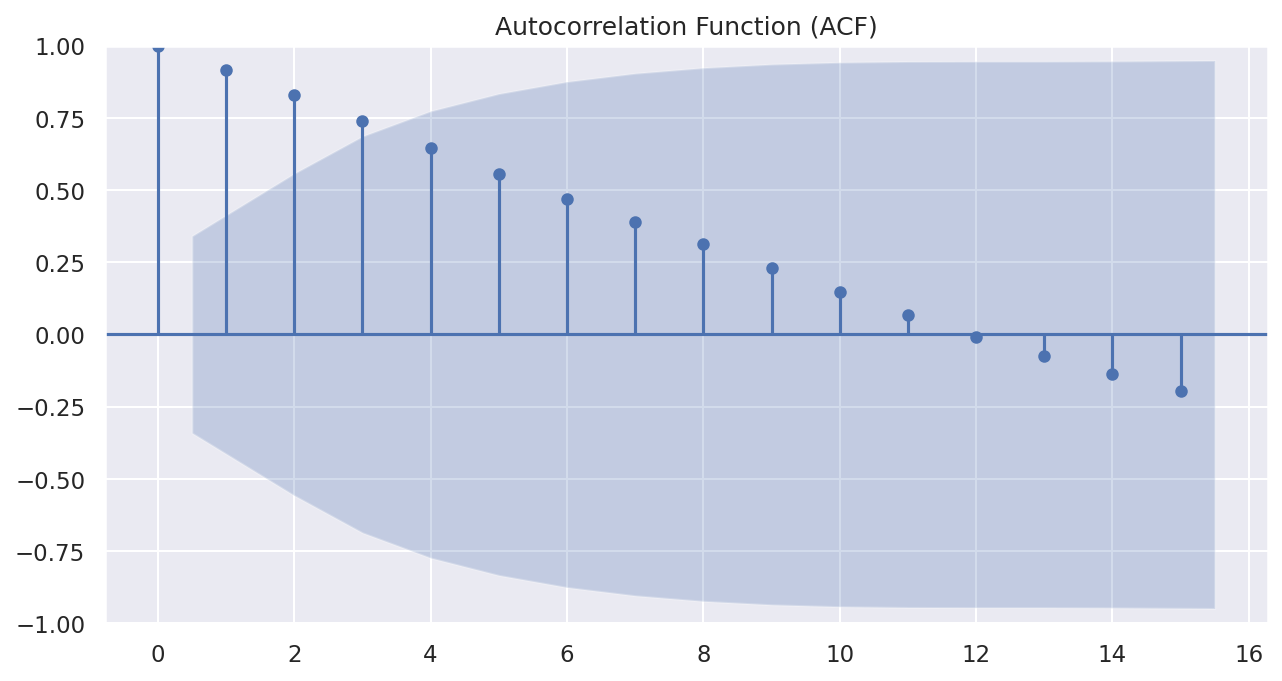

In [ ]:
# Import library seaborn dan matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Setting kedalaman kualitas grafik dalam dpi (deep per inch)
sns.set(
    rc = {
        'figure.figsize' : (10, 5),
        'figure.dpi' : 150
    }
)

plot_acf(df[['hdi']], lags=15)
plt.title('Autocorrelation Function (ACF)')
plt.show()

Grafik ACF menunjukkan autokorelasi yang kuat pada lag awal, menandakan adanya tren dalam data. Penurunan korelasi secara bertahap menunjukkan efek masa lalu tetap terasa, meskipun melemah. Data kemungkinan tidak stasioner dan membutuhkan differencing atau uji tambahan seperti ARIMA untuk analisis lebih lanjut.

# split data

In [ ]:
# Hitung banyak data
banyak_data = df.shape[0]
print(f'Banyak data = {banyak_data}')

# Inisialisasi proporsi yang digunakan
train_proportion = 0.85
test_proportion = 1 - train_proportion

# Hitung banyak data train dan test
train_size = int(banyak_data * train_proportion)
test_size = banyak_data - train_size

# Tampilkan data
print(f'Banyak data train = {train_size}')
print(f'Banyak data test = {test_size}')

Banyak data = 33
Banyak data train = 26
Banyak data test = 7


In [ ]:
# Proses pembagian data
X_train = df.iloc[:train_size]
X_test = df.iloc[train_size:]

# Tampilkan data train
display(X_train)

,hdi
year,
1990-01-01,0.526
1991-01-01,0.533
1992-01-01,0.541
1993-01-01,0.549
1994-01-01,0.560
1995-01-01,0.571
1996-01-01,0.580
1997-01-01,0.590
1998-01-01,0.587


In [ ]:
# Tampilkan data test
display(X_test)

,hdi
year,
2016-01-01,0.701
2017-01-01,0.708
2018-01-01,0.712
2019-01-01,0.718
2020-01-01,0.712
2021-01-01,0.707
2022-01-01,0.713


# Modeling

## 1. ARIMA (AutoRegressive Integrated Moving Average)

ARIMA dirumuskan :

\begin{equation}
y_t = \mu + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q} + \epsilon_t
\end{equation}

ARIMA(p, d, q) memiliki tiga parameter utama:

* p : Order dari model autoregressive (AR)
* d : Jumlah diferensiasi yang diperlukan untuk membuat data stasioner.
* q : Order dari model moving average (MA).

In [ ]:
# Import library plotly untuk visualisasi data
import plotly.express as px

def plot_prediksi(hasil_prediksi, x, y, mae, params = None):
    fig = px.line(
        data_frame = hasil_prediksi,
        x = x,
        y = y,
        color_discrete_sequence = ['#10375C', '#F3C623']
    )

    fig.update_layout(
        width = 1200,
        height = 500,
        showlegend = False,
        plot_bgcolor = 'rgba(0, 0, 0, 0)',
        title = dict(
            text = f"<b>Hasil Prediksi (MAE : {mae})<b><br><sup><sup><span style='color:#000435;font-size:10'>Parameter : {params}</span></sup></sup>",
            font = dict(
                size = 28,
                color = '#757882'
            ),
            y = 0.92,
            x = 0.5
        ),
        yaxis = dict(
            title = '',
            showgrid = False,
            showline = False,
            showticklabels = False,
            zeroline = False,
        ),
        margin = dict(
            t = 80,
            b = 10,
            r = 20
        )
    )

    fig.show(renderer = 'colab')

###  Pencarian Parameter Terbaik ARIMA

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from itertools import product

# Tentukan rentang nilai p, d, q yang akan diuji
p_values = range(0, 6)  # AR term
d_values = range(0, 6)  # Differencing term
q_values = range(0, 6)  # MA term

# Buat grid search untuk kombinasi parameter (p, d, q)
parameters = list(product(p_values, d_values, q_values))

# Fungsi untuk mengevaluasi model ARIMA
def evaluate_arima_model(train, test, p, d, q):
    try:
        # Fit model ARIMA
        model = ARIMA(train, order=(p, d, q))
        model_fit = model.fit()

        # Prediksi dengan model yang telah dilatih
        forecast = model_fit.forecast(steps = test.shape[0])

        #if(d > 0):
            # Mengembalikan hasil prediksi yang sudah di-differencing ke dalam bentuk asli
        #    forecast = X_train.iloc[-1] + forecast.cumsum()

        # Hitung error prediksi
        mae = mean_absolute_error(test, forecast)

        prediksi = test.copy()
        prediksi['predict'] = forecast.tolist()

        plot_prediksi(
            prediksi,
            x = prediksi.index,
            y = ['hdi',	'predict'],
            mae = round(mae, 4),
            params = f'(p={p}, d={d}, q={q})'
        )

        return mae, forecast
    except:
        return np.nan, np.nan  # Jika terjadi error (misal model tidak konvergen), return NaN

# Grid search untuk parameter terbaik
best_mae_ARIMA = float('inf')
best_params_ARIMA = None

for param in parameters:
    p, d, q = param
    mae, forecast = evaluate_arima_model(X_train, X_test, p, d, q)
    if mae < best_mae_ARIMA:
        best_mae_ARIMA = mae
        best_params_ARIMA = param
        best_forecast_ARIMA = forecast

Output hidden; open in https://colab.research.google.com to view.

### Parameter Terbaik ARIMA

In [ ]:
# Output hasil terbaik
print(f"Best Parameters (p, d, q): {best_params_ARIMA}")
print(f"Best Mean Absolute Error: {best_mae_ARIMA}")

Best Parameters (p, d, q): (2, 0, 0)
Best Mean Absolute Error: 0.0034178627241263637


### Model ARIMA dengan Best Parameter

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(X_train, order=(best_params_ARIMA[0], best_params_ARIMA[1], best_params_ARIMA[2]))
model_fit = model.fit()

# Ringkasan model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    hdi   No. Observations:                   26
Model:                 ARIMA(2, 0, 0)   Log Likelihood                  97.233
Date:                Sat, 23 Nov 2024   AIC                           -186.467
Time:                        18:17:25   BIC                           -181.434
Sample:                    01-01-1990   HQIC                          -185.017
                         - 01-01-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6161      0.080      7.711      0.000       0.459       0.773
ar.L1          1.7518      0.205      8.547      0.000       1.350       2.154
ar.L2         -0.7591      0.206     -3.679      0.0

## 2. Double Exponential Smoothing

DES dirumuskan sebagai :      

\begin{equation}
l_t = \alpha\cdot y_{t} + (1-\alpha)(l_{t-1}+b_{t-1})\\
b_t = \beta(l_{t}-l_{t-1})+(1-\beta)b_{t-1}\\
\hat{y}_{t+k} = l_t + k \cdot b_t
\end{equation}

DES(α, β) memiliki dua parameter utama:

* α : Smoothing Level
* β : Smoothing Trend

### Pencarian Parameter Terbaik DES

In [ ]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from itertools import product

# Tentukan rentang nilai p, d, q yang akan diuji
alpha = np.arange(0, 1, 0.1)
beta = np.arange(0, 1, 0.1)

# Buat grid search untuk kombinasi parameter
parameters = list(product(alpha, beta))

# Fungsi untuk mengevaluasi model DSE
def evaluate_exponential_smoothing_model(train, test, alpha, beta):
    try:
        # Double Exponential Smoothing (Holt's Linear Trend)
        model = ExponentialSmoothing(train, trend='add', seasonal=None)
        model_fit = model.fit(smoothing_level=alpha, smoothing_trend=beta)

        # Forecast
        forecast = model_fit.forecast(steps=test.shape[0])

        # Hitung error prediksi
        mae = mean_absolute_error(test, forecast)

        prediksi = test.copy()
        prediksi['predict'] = forecast.tolist()

        plot_prediksi(
            prediksi,
            x = prediksi.index,
            y = ['hdi',	'predict'],
            mae = round(mae, 4),
            params = f'(alpha={alpha:.2f}, beta={beta:.2f})'
        )

        return mae, forecast
    except:
        return np.nan, np.nan  # Jika terjadi error (misal model tidak konvergen), return NaN

# 4. Grid search untuk parameter terbaik
best_mae_DES = float('inf')
best_params_DES = None

for param in parameters:
    alpha, beta = param
    mae, forecast = evaluate_exponential_smoothing_model(X_train, X_test, alpha, beta)
    if mae < best_mae_DES:
        best_mae_DES = mae
        best_params_DES = param
        best_forecast_DES = forecast

### Parameter Terbaik DES

In [ ]:
# Output hasil terbaik
print(f"Best Parameters (alpha, beta): ({best_params_DES[0]:.2f}, {best_params_DES[1]:.2f})")
print(f"Best Mean Absolute Error: {best_mae_DES}")

Best Parameters (alpha, beta): (0.50, 0.90)
Best Mean Absolute Error: 0.007429315323681137


### Model DES dengan Best Parameter

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit ARIMA model
model = ExponentialSmoothing(X_train, trend='add', seasonal=None)
model_fit = model.fit(smoothing_level = best_params_DES[0], smoothing_trend = best_params_DES[1])

# Ringkasan model
print(model_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                      hdi   No. Observations:                   26
Model:             ExponentialSmoothing   SSE                              0.001
Optimized:                         True   AIC                           -270.836
Trend:                         Additive   BIC                           -265.804
Seasonal:                          None   AICC                          -266.415
Seasonal Periods:                  None   Date:                 Sat, 23 Nov 2024
Box-Cox:                          False   Time:                         18:17:35
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5000000                alpha                False
smoothing_trend            0.90000

## FB Prophet

In [ ]:
X_train = X_train.reset_index()

# Untuk fbprophet kolom tanggal diberi nama ds dan kolom nilai diberi nama y
X_train = X_train.rename(columns = {
    'year' : 'ds',
    'hdi' : 'y'
})

### Pencarian Parameter Terbaik FB Prophet

In [ ]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error
from datetime import timedelta

# Menentukan parameter grid untuk tuning
param_grid = {
    'daily_seasonality': [False, True],
    'weekly_seasonality': [False, True],
    'yearly_seasonality': [False, True],
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1, 10, 20],
    'seasonality_mode' : ['additive', 'multiplicative'],
}

# Menyimpan hasil
results = list()

# Melakukan grid search
for params in ParameterGrid(param_grid):
    model = Prophet(**params)
    model.fit(X_train)

    # Membuat prediksi
    future = model.make_future_dataframe(periods = X_test.shape[0], freq='Y')
    forecast = model.predict(future)

    # Menghitung MAE untuk data test
    mae = mean_absolute_error(X_test['hdi'], forecast.iloc[train_size:]['yhat'])
    results.append({'params': params, 'mae': mae})

    forecast_test = forecast.iloc[train_size:][['ds', 'yhat']]
    forecast_test['ds'] = forecast_test['ds'].apply(lambda x : x + timedelta(days=1) if x.day == 31 else x)

    hasil_prediksi = X_test.reset_index().merge(forecast_test, left_on = 'year', right_on = 'ds', how = 'left').drop('ds', axis = 1)

    plot_prediksi(
        hasil_prediksi,
        x = 'year',
        y = ['hdi', 'yhat'],
        mae = round(mae, 4),
        params = params
    )

    if(len(results) == 1):
        best_mae = mae
        best_params = params
        best_forecast = forecast
    else:
        if(mae < best_mae):
            best_mae = mae
            best_params = params
            best_forecast = forecast

INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/p9rdgir5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/ocmc8z9n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47202', 'data', 'file=/tmp/tmp654m832o/p9rdgir5.json', 'init=/tmp/tmp654m832o/ocmc8z9n.json', 'output', 'file=/tmp/tmp654m832o/prophet_modeluqzhjvb1/prophet_model-20241123181735.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:17:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:17:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/kzun2499.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/_v94plc6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69722', 'data', 'file=/tmp/tmp654m832o/kzun2499.json', 'init=/tmp/tmp654m832o/_v94plc6.json', 'output', 'file=/tmp/tmp654m832o/prophet_model4zg7b11s/prophet_model-20241123181736.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:17:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:17:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/d8octkfs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/jwlwv0j5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=21638', 'data', 'file=/tmp/tmp654m832o/d8octkfs.json', 'init=/tmp/tmp654m832o/jwlwv0j5.json', 'output', 'file=/tmp/tmp654m832o/prophet_model60l2ml8e/prophet_model-20241123181736.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:17:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:17:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/j50fzt19.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/7ljbohcf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40310', 'data', 'file=/tmp/tmp654m832o/j50fzt19.json', 'init=/tmp/tmp654m832o/7ljbohcf.json', 'output', 'file=/tmp/tmp654m832o/prophet_modelvy_7lmhu/prophet_model-20241123181736.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:17:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:17:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/2z16neo2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/4p96mpch.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=71129', 'data', 'file=/tmp/tmp654m832o/2z16neo2.json', 'init=/tmp/tmp654m832o/4p96mpch.json', 'output', 'file=/tmp/tmp654m832o/prophet_model7td_w1c5/prophet_model-20241123181737.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:17:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:17:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


...

INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/efxrpq_2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/_w3km9zh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24436', 'data', 'file=/tmp/tmp654m832o/efxrpq_2.json', 'init=/tmp/tmp654m832o/_w3km9zh.json', 'output', 'file=/tmp/tmp654m832o/prophet_modely95y6mpg/prophet_model-20241123182912.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:29:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/4qvfz2vj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/2w6039it.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=74114', 'data', 'file=/tmp/tmp654m832o/4qvfz2vj.json', 'init=/tmp/tmp654m832o/2w6039it.json', 'output', 'file=/tmp/tmp654m832o/prophet_modelmobif41z/prophet_model-20241123182937.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:29:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/lw9zvafm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/p83mnj0w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50668', 'data', 'file=/tmp/tmp654m832o/lw9zvafm.json', 'init=/tmp/tmp654m832o/p83mnj0w.json', 'output', 'file=/tmp/tmp654m832o/prophet_modeltd4hvi6b/prophet_model-20241123182938.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:29:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/djc9ierv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/r5ydodtp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=7548', 'data', 'file=/tmp/tmp654m832o/djc9ierv.json', 'init=/tmp/tmp654m832o/r5ydodtp.json', 'output', 'file=/tmp/tmp654m832o/prophet_model7yxa1nz0/prophet_model-20241123182940.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:29:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/p3c6y_vz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/0455loab.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1302', 'data', 'file=/tmp/tmp654m832o/p3c6y_vz.json', 'init=/tmp/tmp654m832o/0455loab.json', 'output', 'file=/tmp/tmp654m832o/prophet_model5y11antb/prophet_model-20241123182954.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:29:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


### Parameter Terbaik FB Prophet

In [ ]:
print(best_params)

{'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10, 'weekly_seasonality': True, 'yearly_seasonality': True}


In [ ]:
# Output hasil terbaik
print(f"Best Parameters FB Prophet: {best_params}")
print(f"Best Mean Absolute Error: {best_mae}")

Best Parameters FB Prophet: {'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10, 'weekly_seasonality': True, 'yearly_seasonality': True}
Best Mean Absolute Error: 0.010058742536112386


### Model FB Prophet dengan Best Parameter

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from datetime import timedelta

model = Prophet(
    changepoint_prior_scale = 0.01,
    daily_seasonality = True,
    seasonality_mode = 'multiplicative',
    seasonality_prior_scale = 10,
    weekly_seasonality = True,
    yearly_seasonality = True
)

model.fit(X_train)

# Membuat prediksi
future = model.make_future_dataframe(periods = X_test.shape[0], freq='Y')
forecast = model.predict(future)

forecast['ds'] = forecast['ds'].apply(lambda x : x + timedelta(days=1) if x.day == 31 else x)

# Menghitung MAE untuk data test
mae = mean_absolute_error(X_test['hdi'], forecast.iloc[train_size:]['yhat'])

forecast_test = forecast.iloc[train_size:][['ds', 'yhat']]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/ugpfzruv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp654m832o/l4i98vn9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60452', 'data', 'file=/tmp/tmp654m832o/ugpfzruv.json', 'init=/tmp/tmp654m832o/l4i98vn9.json', 'output', 'file=/tmp/tmp654m832o/prophet_modelf4vzcz8u/prophet_model-20241123183231.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
18:32:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:32:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
print(mae)

0.010058742536112386


# FInal Model

<h1> dari ketiga model, model yang terbaik adalah ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(df['hdi'], order=(2, 0, 0))
model_fit = model.fit()

# Ringkasan model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    hdi   No. Observations:                   33
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 122.522
Date:                Sun, 24 Nov 2024   AIC                           -237.045
Time:                        07:38:08   BIC                           -231.059
Sample:                    01-01-1990   HQIC                          -235.031
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6360      0.045     14.172      0.000       0.548       0.724
ar.L1          1.6554      0.172      9.615      0.000       1.318       1.993
ar.L2         -0.6696      0.178     -3.755      0.0

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



In [ ]:
df['type'] = 'Actual'

In [ ]:
df

,hdi,type
year,,
1990-01-01,0.526,Actual
1991-01-01,0.533,Actual
1992-01-01,0.541,Actual
1993-01-01,0.549,Actual
1994-01-01,0.560,Actual
1995-01-01,0.571,Actual
1996-01-01,0.580,Actual
1997-01-01,0.590,Actual
1998-01-01,0.587,Actual


In [ ]:
# Prediksi hingga beberapa tahun kedepan
forecast = model_fit.forecast(steps = 8).to_frame()

forecast = forecast.rename(columns = {0 : 'hdi'})
forecast = pd.concat([df.iloc[-1:], forecast])

forecast['type'] = 'Forecast'

In [ ]:
forecast.head()

,hdi,type,predicted_mean
2022-01-01,0.713,Forecast,NaN
2023-01-01,NaN,Forecast,0.715929
2024-01-01,NaN,Forecast,0.716759
2025-01-01,NaN,Forecast,0.716173
2026-01-01,NaN,Forecast,0.714647


In [ ]:
forecast['hdi'] = forecast['hdi'].fillna(forecast['predicted_mean'])
forecast = forecast.drop('predicted_mean', axis=1)

In [ ]:
full_forecast = pd.concat([df, forecast])

In [ ]:
full_forecast

,hdi,type
1990-01-01,0.526000,Actual
1991-01-01,0.533000,Actual
1992-01-01,0.541000,Actual
1993-01-01,0.549000,Actual
1994-01-01,0.560000,Actual
1995-01-01,0.571000,Actual
1996-01-01,0.580000,Actual
1997-01-01,0.590000,Actual
1998-01-01,0.587000,Actual
1999-01-01,0.592000,Actual


In [ ]:
# Import library plotly untuk visualisasi data
import plotly.express as px

fig = px.line(
    data_frame = full_forecast,
    x = full_forecast.index,
    y = 'hdi',
    color = 'type',
    color_discrete_sequence = ['#78B3CE', '#F3C623']
)

fig.add_trace(
    px.scatter(
        data_frame = full_forecast.iloc[:1],
        x = full_forecast.iloc[:1].index,
        y = 'hdi',
        size = [3],
        # Pewarnaan pada scatter chart
        color_discrete_sequence = ['#000435'],
    ).data[0]
)


fig.add_annotation(
    x = full_forecast.iloc[:1].index.date[0],
    y = full_forecast.iloc[:1]['hdi'].values[0],
    text = f"Tahun 1990",
    yanchor = 'bottom',
    showarrow = False,
    font = dict(
        size = 12,
        color = "#544018",
        family = "sans serif"
    ),
    align = "left",
    yshift = 20,
    opacity = 0.8
)

fig.add_trace(
    px.scatter(
        data_frame = full_forecast.iloc[-1:],
        x = full_forecast.iloc[-1:].index,
        y = 'hdi',
        size = [3],
        # Pewarnaan pada scatter chart
        color_discrete_sequence = ['#F3C623'],
    ).data[0]
)

# Annotation untuk tahun 2030
fig.add_annotation(
    x = full_forecast.iloc[-1:].index.date[0],
    y = full_forecast.iloc[-1:]['hdi'].values[0],
    text = f"Di Tahun 2030 Mendatang,<br>"
            "Ternyata HDI di indonesia akan Sedikit Menurun<br>",
    yanchor = 'bottom',
    showarrow = False,
    font = dict(
        size = 12,
        color = "#544018",
        family = "sans serif"
    ),
    align = "left",
    yshift = 20,
    opacity = 0.8
)

fig.update_layout(
    width = 1200,
    height = 500,
    showlegend = False,
    plot_bgcolor = 'rgba(0, 0, 0, 0)',
    title = dict(
        text = f"<b>Apakah di Tahun 2030,<br> TREN HDI di Indonesia diprediksi akan terus meningkat?",
        font = dict(
            size = 17,
            color = '#757882'
        ),
        y = 0.92,
        x = 0.5
    ),
    yaxis = dict(
        title = '',
        showgrid = False,
        showline = False,
        showticklabels = False,
        zeroline = False,
    ),
    margin = dict(
        t = 80,
        b = 10,
        r = 20
    )
)

fig.show(renderer = 'colab')

In [ ]:
full_forecast.to_csv('MODEL DATA HDI.csv', index=True)